In [22]:
from matplotlib.colors import BoundaryNorm, ListedColormap
from pathlib import Path
from scipy.optimize import curve_fit
from scipy.stats import linregress
import math
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import re
import seaborn as sns

from country_config import *
from run_config import *
from utils import *

### Fit beta

In [23]:
analysis_path = Path(calibration_analysis_path)
analysis_path.mkdir(exist_ok=True)
print(f"Created analysis directory at {analysis_path.resolve()}")
input_df = pd.read_csv(f"{CALIBRATION_RUN_INPUTS_DIR}/inputs.csv")
# output_path = calibration_path / "output"
output_path = Path(f"{calibration_path}/output")

Created analysis directory at /work/tuv89272/Calibration_Pipeline_v6_NG-SE/calibration_10_one_pattern_25_replicates/analysis


In [24]:
# Build keys from inputs.csv
input_df = input_df.copy()
input_df["input_row"] = np.arange(len(input_df))
input_df["beta_key"] = input_df["beta"].astype(float).map(lambda x: f"{x:.4f}")
input_df["access_key"] = input_df["access_rate"].astype(float).map(lambda x: f"{x:.3f}")
input_df["district_id"] = input_df["district_id"].astype(int)
input_df["population_bin"] = input_df["population_bin"].astype(int)

# Example:
# calibration_beta_0.0010_access_52.700_district_32_pop_1217_monthly_data_0.db
pat = re.compile(
    r"^calibration_beta_(?P<beta>[0-9.eE+-]+)_"
    r"access_(?P<access>[0-9.eE+-]+)_"
    r"district_(?P<district>\d+)_"
    r"pop_(?P<pop>\d+)_"
    r"monthly_data_(?P<rep>\d+)\.db$"
)

records = []

for f in output_path.glob("calibration_beta_*_access_*_district_*_pop_*_monthly_data_*.db"):
    m = pat.match(f.name)
    if not m:
        continue

    rep = int(m.group("rep"))

    # keep only requested reps: 1 to reps
    if rep < 1 or rep > calibration_replicates:
        continue

    records.append({
        "output_file": f,
        "beta_key": f"{float(m.group('beta')):.4f}",
        "access_key": f"{float(m.group('access')):.3f}",
        "district_id": int(m.group("district")),
        "population_bin": int(m.group("pop")),
        "rep": rep,
    })

output_df = pd.DataFrame(records)

print(f"Input rows: {len(input_df)}")
print(f"Parsed output files with rep 0-{calibration_replicates-1}: {len(output_df)}")

matched = output_df.merge(
    input_df[
        [
            "input_row",
            "input_file",
            "beta_key",
            "access_key",
            "district_id",
            "population_bin",
        ]
    ],
    on=["beta_key", "access_key", "district_id", "population_bin"],
    how="inner",
)

matched = matched.sort_values(["input_row", "rep"]).reset_index(drop=True)

output_files = matched["output_file"].tolist()

print(f"Matched output files: {len(output_files)}")

Input rows: 570
Parsed output files with rep 0-24: 14250
Matched output files: 14250


In [25]:
expected_reps = set(range(1, calibration_replicates + 1))

counts = (
    matched.groupby(
        ["input_row", "input_file", "beta_key", "access_key", "district_id", "population_bin"]
    )
    .agg(
        n_files=("output_file", "count"),
        reps_found=("rep", lambda x: sorted(set(x))),
    )
    .reset_index()
)

counts["missing_reps"] = counts["reps_found"].apply(
    lambda found: sorted(expected_reps - set(found))
)

incomplete = counts[counts["missing_reps"].map(len) > 0]

# # artificially create fake data in the incomplete df
# incomplete = pd.DataFrame({
#     "input_file": ["sample_1.txt", "sample_2.txt"],
#     "n_files": [5, 5],
#     "reps_found": [3, 4],
#     "missing_reps": [["rep4", "rep5"], ["rep1"]]
# })

if incomplete.empty:
    ok("All input rows have the expected number of reps.")
else:
    warn(f"Input rows with missing reps: {len(incomplete)}")

print("Incomplete rows (missing reps):")
incomplete[["input_file", "n_files", "reps_found", "missing_reps"]].head(30)

✓ All input rows have the expected number of reps.
Incomplete rows (missing reps):


,input_file,n_files,reps_found,missing_reps


In [26]:
start_date = pd.Timestamp(f"{initial_year}-01-01")
end_date = pd.Timestamp(f"{calibration_year}-01-01")
calibration_date_from = pd.Timestamp(f"{calibration_year-1}-01-01")
calibration_date_to = pd.Timestamp(f"{calibration_year}-01-01")
calibration_month_from = (calibration_date_from.year - start_date.year) * 12 + (calibration_date_from.month - start_date.month)
calibration_month_to = (calibration_date_to.year - start_date.year) * 12 + (calibration_date_to.month - start_date.month)
total_month = (end_date.year - start_date.year) * 12 + (end_date.month - start_date.month)
print('calibration_month_from', calibration_month_from,f'({calibration_date_from})')
print('calibration_month_to', calibration_month_to,f'({calibration_date_to})')
print('total_month', total_month)

calibration_means_path = analysis_path / "calibration_means.csv"
if calibration_means_path.exists():
    print(f"Found existing summary means at {calibration_means_path}. Loading...")
    summary = pd.read_csv(calibration_means_path)
else:
    # Use the first file to determine the end month
    summary = pd.DataFrame(
        columns=["access_rate", "beta", "district_id", "population_bin", "rep",
                    "pfpr_under5", "pfpr_2to10", "pfpr_all"],
    )

    for count, file in enumerate(output_files, 1):
        data = get_table(file, "monthly_site_data_district")
        sim_end_month = sorted(data["monthly_data_id"].unique())[-1]

        if calibration_month_to >= sim_end_month:
            warn(f"Warning: Expected calibration_month_to {calibration_month_to} but found {sim_end_month} in file {file}. This may indicate an issue with the simulation output.")

        parts = file.stem.split("_")
        # print(parts)
        beta, access, district_id,population_bin, rep = float(parts[2]), float(parts[4]), int(parts[6]),int(parts[8]), int(parts[11])

        data = data.loc[data["monthly_data_id"].between(calibration_month_from, calibration_month_to, inclusive="left")]
        summary.loc[file.stem] = data[["pfpr_under5", "pfpr_2to10", "pfpr_all"]].mean()
        summary.loc[file.stem, "district_id"] = district_id
        summary.loc[file.stem, "population_bin"] = int(population_bin)
        summary.loc[file.stem, "access_rate"] = access
        summary.loc[file.stem, "beta"] = beta
        summary.loc[file.stem, "rep"] = rep

        # print(count, file, "beta:", beta, "access:", access, "district_id:", district_id, "population_bin:", population_bin, "rep:", rep)
        if count % 500 == 0:
            print(f"Processed {count} of {len(output_files)} files ({file})")

    # Convert percentages → fractions, then average over iterations
    for col in ("pfpr_under5", "pfpr_2to10", "pfpr_all"):
        summary[col] = summary[col].div(100)

    pfpr_cols = ["pfpr_under5", "pfpr_2to10", "pfpr_all"]

    agg_map = {}
    for c in pfpr_cols:
        agg_map[c] = (c, "mean")
        agg_map[f"{c}_std"] = (c, "std")

    summary = (
        summary.drop(columns=["rep"])
        .groupby(["district_id", "beta", "access_rate", "population_bin"])
        .agg(**agg_map)
        .reset_index()
    )
    summary.to_csv(calibration_means_path, index=False)

calibration_month_from 144 (2023-01-01 00:00:00)
calibration_month_to 156 (2024-01-01 00:00:00)
total_month 156
Found existing summary means at calibration_10_one_pattern_25_replicates/analysis/calibration_means.csv. Loading...


In [27]:
summary

,district_id,beta,access_rate,population_bin,pfpr_under5,pfpr_under5_std,pfpr_2to10,pfpr_2to10_std,pfpr_all,pfpr_all_std
0,7.0,0.001,0.731,1320.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,7.0,0.001,0.731,2628.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,7.0,0.001,0.731,4868.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
3,7.0,0.001,0.731,11052.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,7.0,0.001,0.731,53285.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...
565,35.0,1.100,0.468,219.0,0.498469,0.049494,0.321081,0.030945,0.305947,0.025962
566,35.0,1.100,0.468,558.0,0.494561,0.036726,0.316743,0.020738,0.296345,0.019013
567,35.0,1.100,0.468,1197.0,0.506714,0.023080,0.326352,0.015451,0.307691,0.009607
568,35.0,1.100,0.468,3072.0,0.506286,0.014894,0.321838,0.011515,0.304447,0.005429


In [28]:
means = pd.read_csv(f"{analysis_path}/calibration_means.csv")
district_ids = means["district_id"].unique()
access_rates = means["access_rate"].unique()
population_bins = means["population_bin"].unique()
betas = means["beta"].unique()

In [29]:
# means = means[means["pfpr_2to10"] > 0.0]
means

,district_id,beta,access_rate,population_bin,pfpr_under5,pfpr_under5_std,pfpr_2to10,pfpr_2to10_std,pfpr_all,pfpr_all_std
0,7.0,0.001,0.731,1320.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,7.0,0.001,0.731,2628.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,7.0,0.001,0.731,4868.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
3,7.0,0.001,0.731,11052.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,7.0,0.001,0.731,53285.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...
565,35.0,1.100,0.468,219.0,0.498469,0.049494,0.321081,0.030945,0.305947,0.025962
566,35.0,1.100,0.468,558.0,0.494561,0.036726,0.316743,0.020738,0.296345,0.019013
567,35.0,1.100,0.468,1197.0,0.506714,0.023080,0.326352,0.015451,0.307691,0.009607
568,35.0,1.100,0.468,3072.0,0.506286,0.014894,0.321838,0.011515,0.304447,0.005429


Unique (district_id, population_bin, access_rate) combinations: 30
1/30 Plotting district_id=7.0, population_bin=1320.0, access_rate=0.731
2/30 Plotting district_id=7.0, population_bin=2628.0, access_rate=0.731
3/30 Plotting district_id=7.0, population_bin=4868.0, access_rate=0.731
4/30 Plotting district_id=7.0, population_bin=11052.0, access_rate=0.731
5/30 Plotting district_id=7.0, population_bin=53285.0, access_rate=0.731
6/30 Plotting district_id=9.0, population_bin=290.0, access_rate=0.584
7/30 Plotting district_id=9.0, population_bin=1039.0, access_rate=0.584
8/30 Plotting district_id=9.0, population_bin=2779.0, access_rate=0.584
9/30 Plotting district_id=9.0, population_bin=7269.0, access_rate=0.584
10/30 Plotting district_id=9.0, population_bin=41397.0, access_rate=0.584
11/30 Plotting district_id=11.0, population_bin=4275.0, access_rate=0.720
12/30 Plotting district_id=11.0, population_bin=7301.0, access_rate=0.720
13/30 Plotting district_id=11.0, population_bin=12018.0, acces

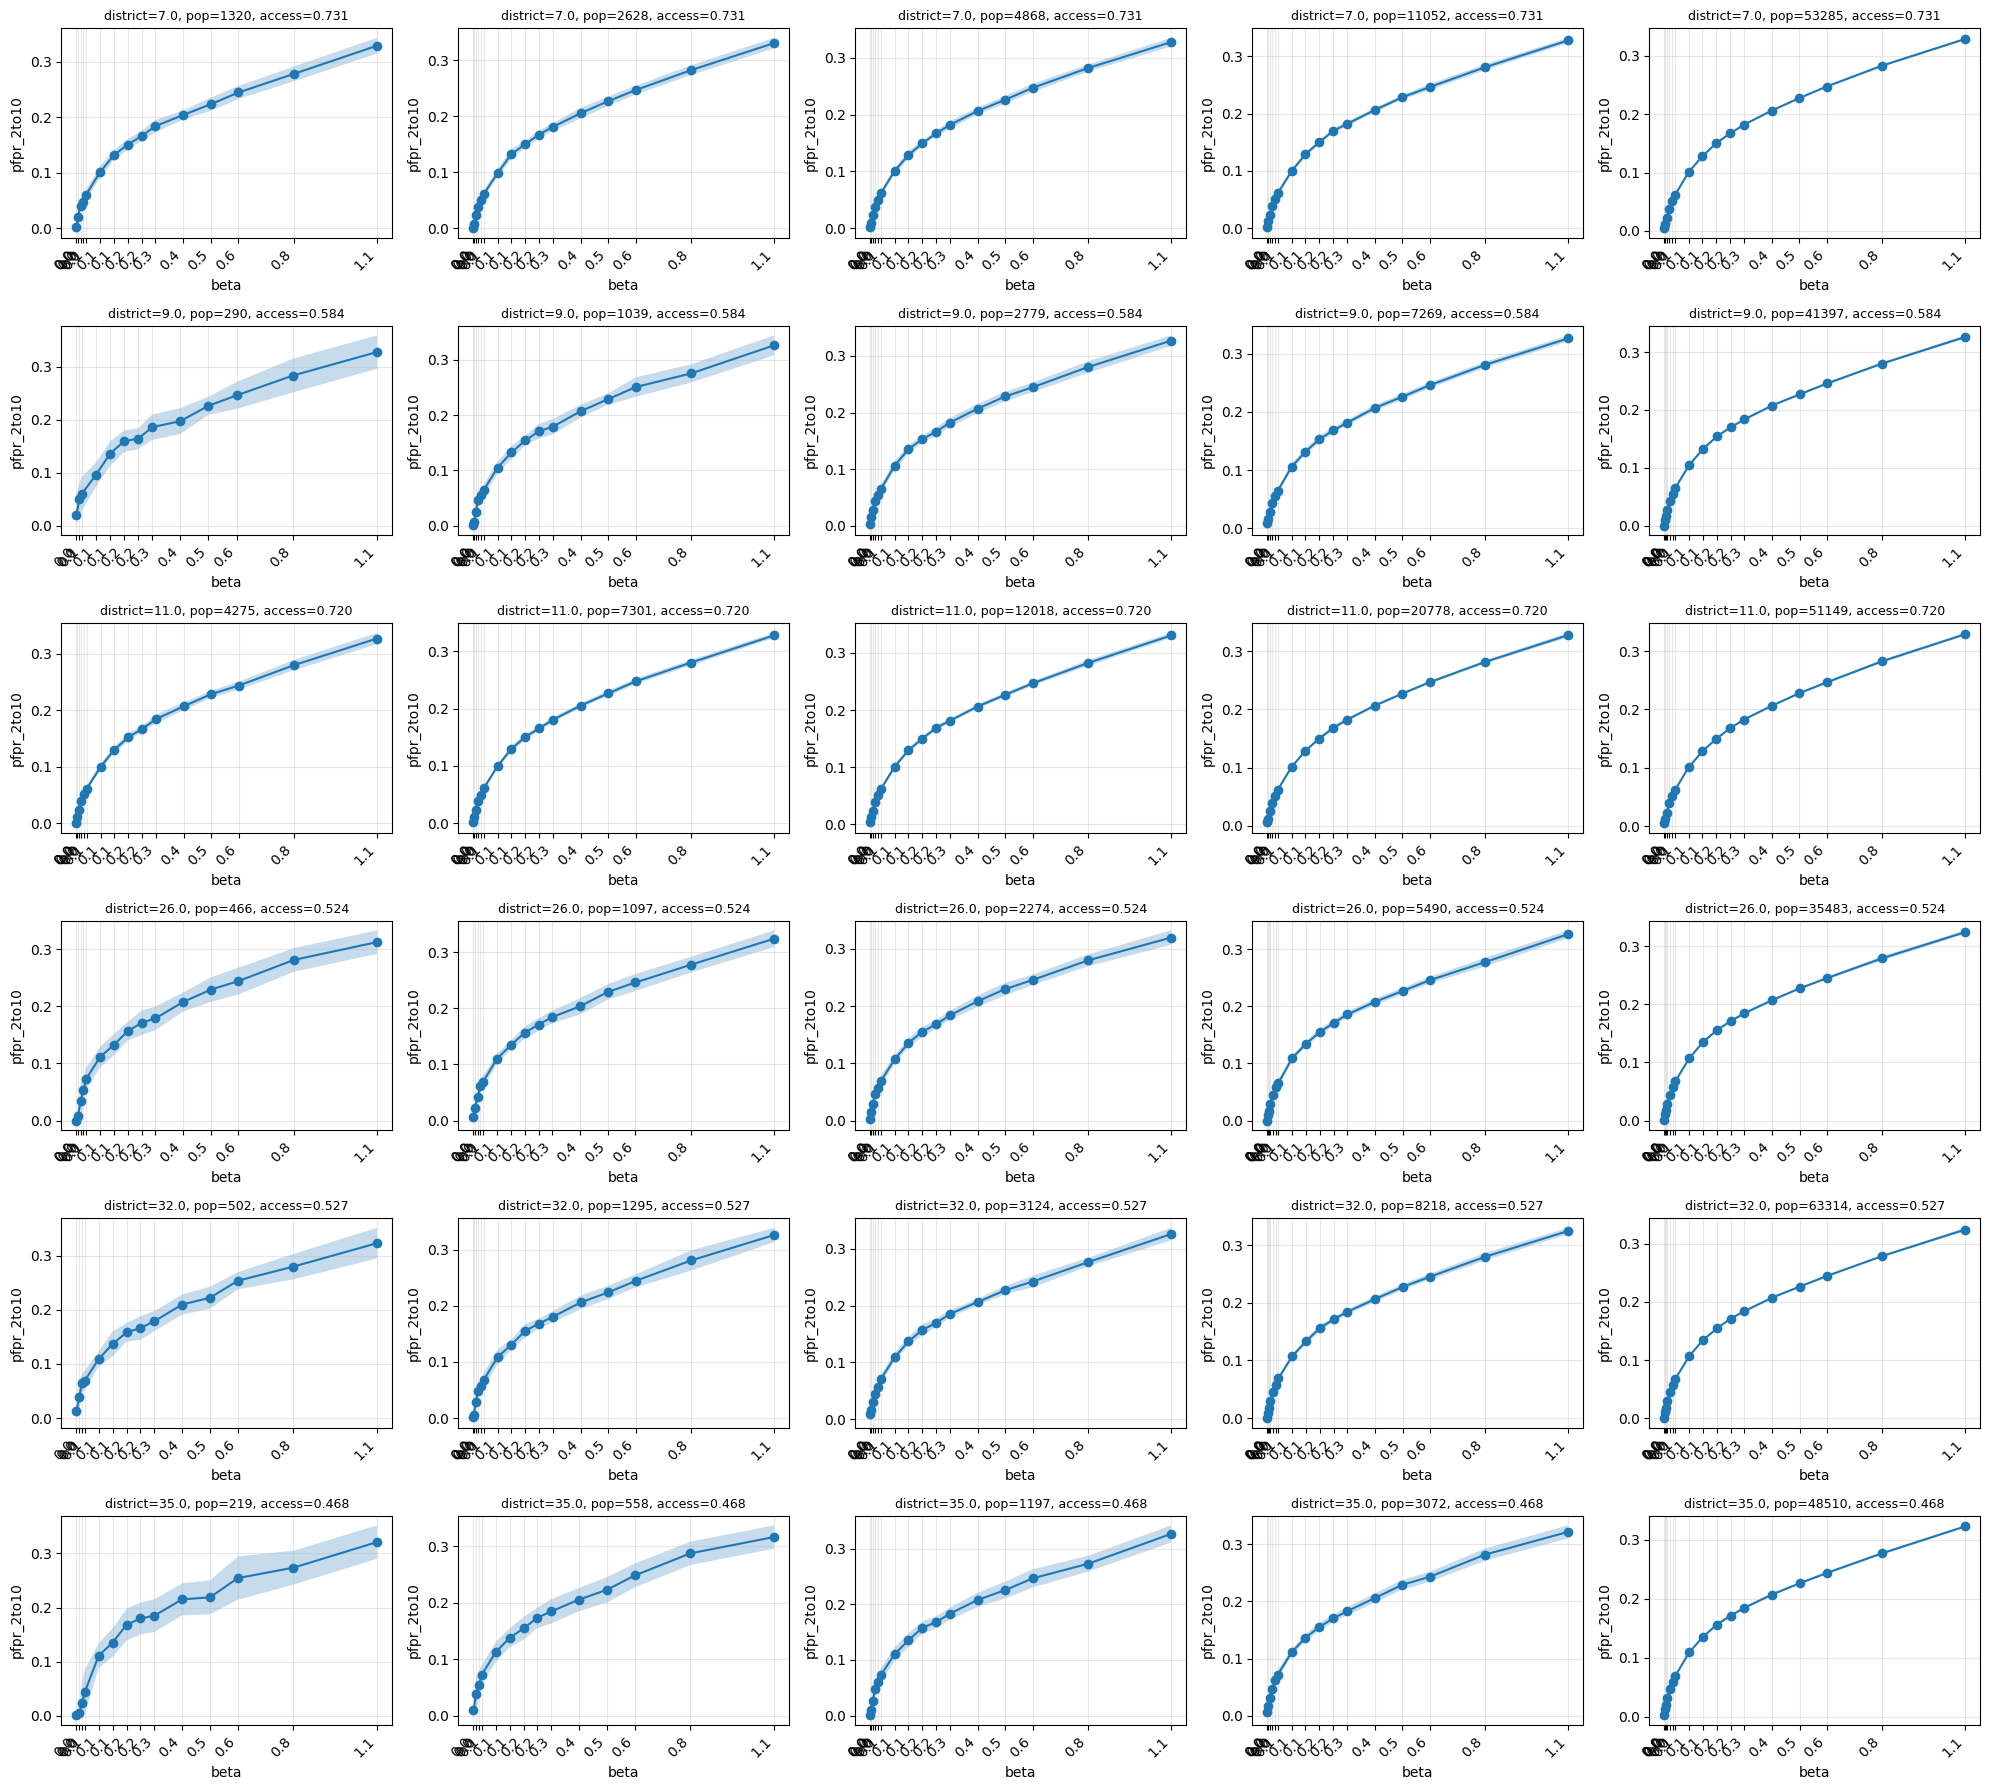

<Figure size 640x480 with 0 Axes>

In [ ]:
df = means.copy()

pfpr_col = "pfpr_2to10"          # or pfpr_under5 / pfpr_all
std_col  = f"{pfpr_col}_std"     # matches the *_std names from .agg()

# keep only rows that really have data (include the std col)
plot_df = df.dropna(subset=["district_id", "beta", "population_bin", "access_rate", pfpr_col]).copy()
plot_df = plot_df[plot_df[pfpr_col] > 0].copy()

grouped = (
    plot_df.groupby(["district_id", "population_bin", "access_rate"])
    .filter(lambda g: len(g) >= 1)
    .sort_values(["district_id", "population_bin", "access_rate", "beta"])
)

grouped.to_csv(f"{analysis_path}/calibration_means_filtered_for_plotting.csv", index=False)

pairs = (
    grouped[["district_id", "population_bin", "access_rate"]]
    .drop_duplicates()
    .sort_values(["district_id", "population_bin", "access_rate"])
    .values.tolist()
)

print(f"Unique (district_id, population_bin, access_rate) combinations: {len(pairs)}")

n = len(pairs)
ncols = 5
nrows = math.ceil(n / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(4*ncols, 3*nrows), squeeze=False)
axes = axes.flatten()

index = 0

for ax, (unit_id, pop_bin, access_rate) in zip(axes, pairs):
    index += 1
    print(f"{index}/{len(pairs)} Plotting district_id={unit_id}, population_bin={pop_bin}, access_rate={access_rate:.3f}")
    g = grouped[
        (grouped["district_id"] == unit_id) &
        (grouped["population_bin"] == pop_bin) &
        (grouped["access_rate"] == access_rate)
    ].sort_values("beta")

    x    = g["beta"].to_numpy()
    mean = g[pfpr_col].to_numpy()
    # std may be NaN for single-rep groups; treat those as 0-width band
    std  = g[std_col].to_numpy() if std_col in g else None

    ax.plot(x, mean, marker="o", linewidth=1.5, label="mean")

    if std is not None:
        std_filled = pd.Series(std).fillna(0).to_numpy()
        lower = mean - std_filled
        upper = mean + std_filled
        # PfPR is a fraction in [0,1]; clip so the band doesn't dip below 0
        lower = lower.clip(min=0)
        ax.fill_between(x, lower, upper, alpha=0.25, label="±1 std")

    ax.set_title(f"district={unit_id}, pop={pop_bin:g}, access={access_rate:.3f}", fontsize=9)
    ax.set_ylabel(pfpr_col)
    ax.set_xlabel("beta")
    ax.grid(True, alpha=0.3)

    # show at most 4 beta ticks per subplot
    beta_vals = g["beta"].tolist()
    max_ticks = 25
    if len(beta_vals) <= max_ticks:
        tick_vals = beta_vals
    else:
        step = math.ceil(len(beta_vals) / max_ticks)
        tick_vals = beta_vals[::step]
        if tick_vals[-1] != beta_vals[-1]:
            tick_vals.append(beta_vals[-1])

    ax.set_xticks(tick_vals)
    ax.set_xticklabels([f"{b:.1f}" for b in tick_vals], rotation=45, ha="right")

for ax in axes[len(pairs):]:
    ax.axis("off")

plt.tight_layout()
plt.show()
# plt.savefig(f"{analysis_path}/calibration_means_plots.png", dpi=300)

1/30 Plotting district_id=7.0, population_bin=1320.0, access_rate=0.731
2/30 Plotting district_id=7.0, population_bin=2628.0, access_rate=0.731
3/30 Plotting district_id=7.0, population_bin=4868.0, access_rate=0.731
4/30 Plotting district_id=7.0, population_bin=11052.0, access_rate=0.731
5/30 Plotting district_id=7.0, population_bin=53285.0, access_rate=0.731
6/30 Plotting district_id=9.0, population_bin=290.0, access_rate=0.584
7/30 Plotting district_id=9.0, population_bin=1039.0, access_rate=0.584
8/30 Plotting district_id=9.0, population_bin=2779.0, access_rate=0.584
9/30 Plotting district_id=9.0, population_bin=7269.0, access_rate=0.584
10/30 Plotting district_id=9.0, population_bin=41397.0, access_rate=0.584
11/30 Plotting district_id=11.0, population_bin=4275.0, access_rate=0.720
12/30 Plotting district_id=11.0, population_bin=7301.0, access_rate=0.720
13/30 Plotting district_id=11.0, population_bin=12018.0, access_rate=0.720
14/30 Plotting district_id=11.0, population_bin=20778.

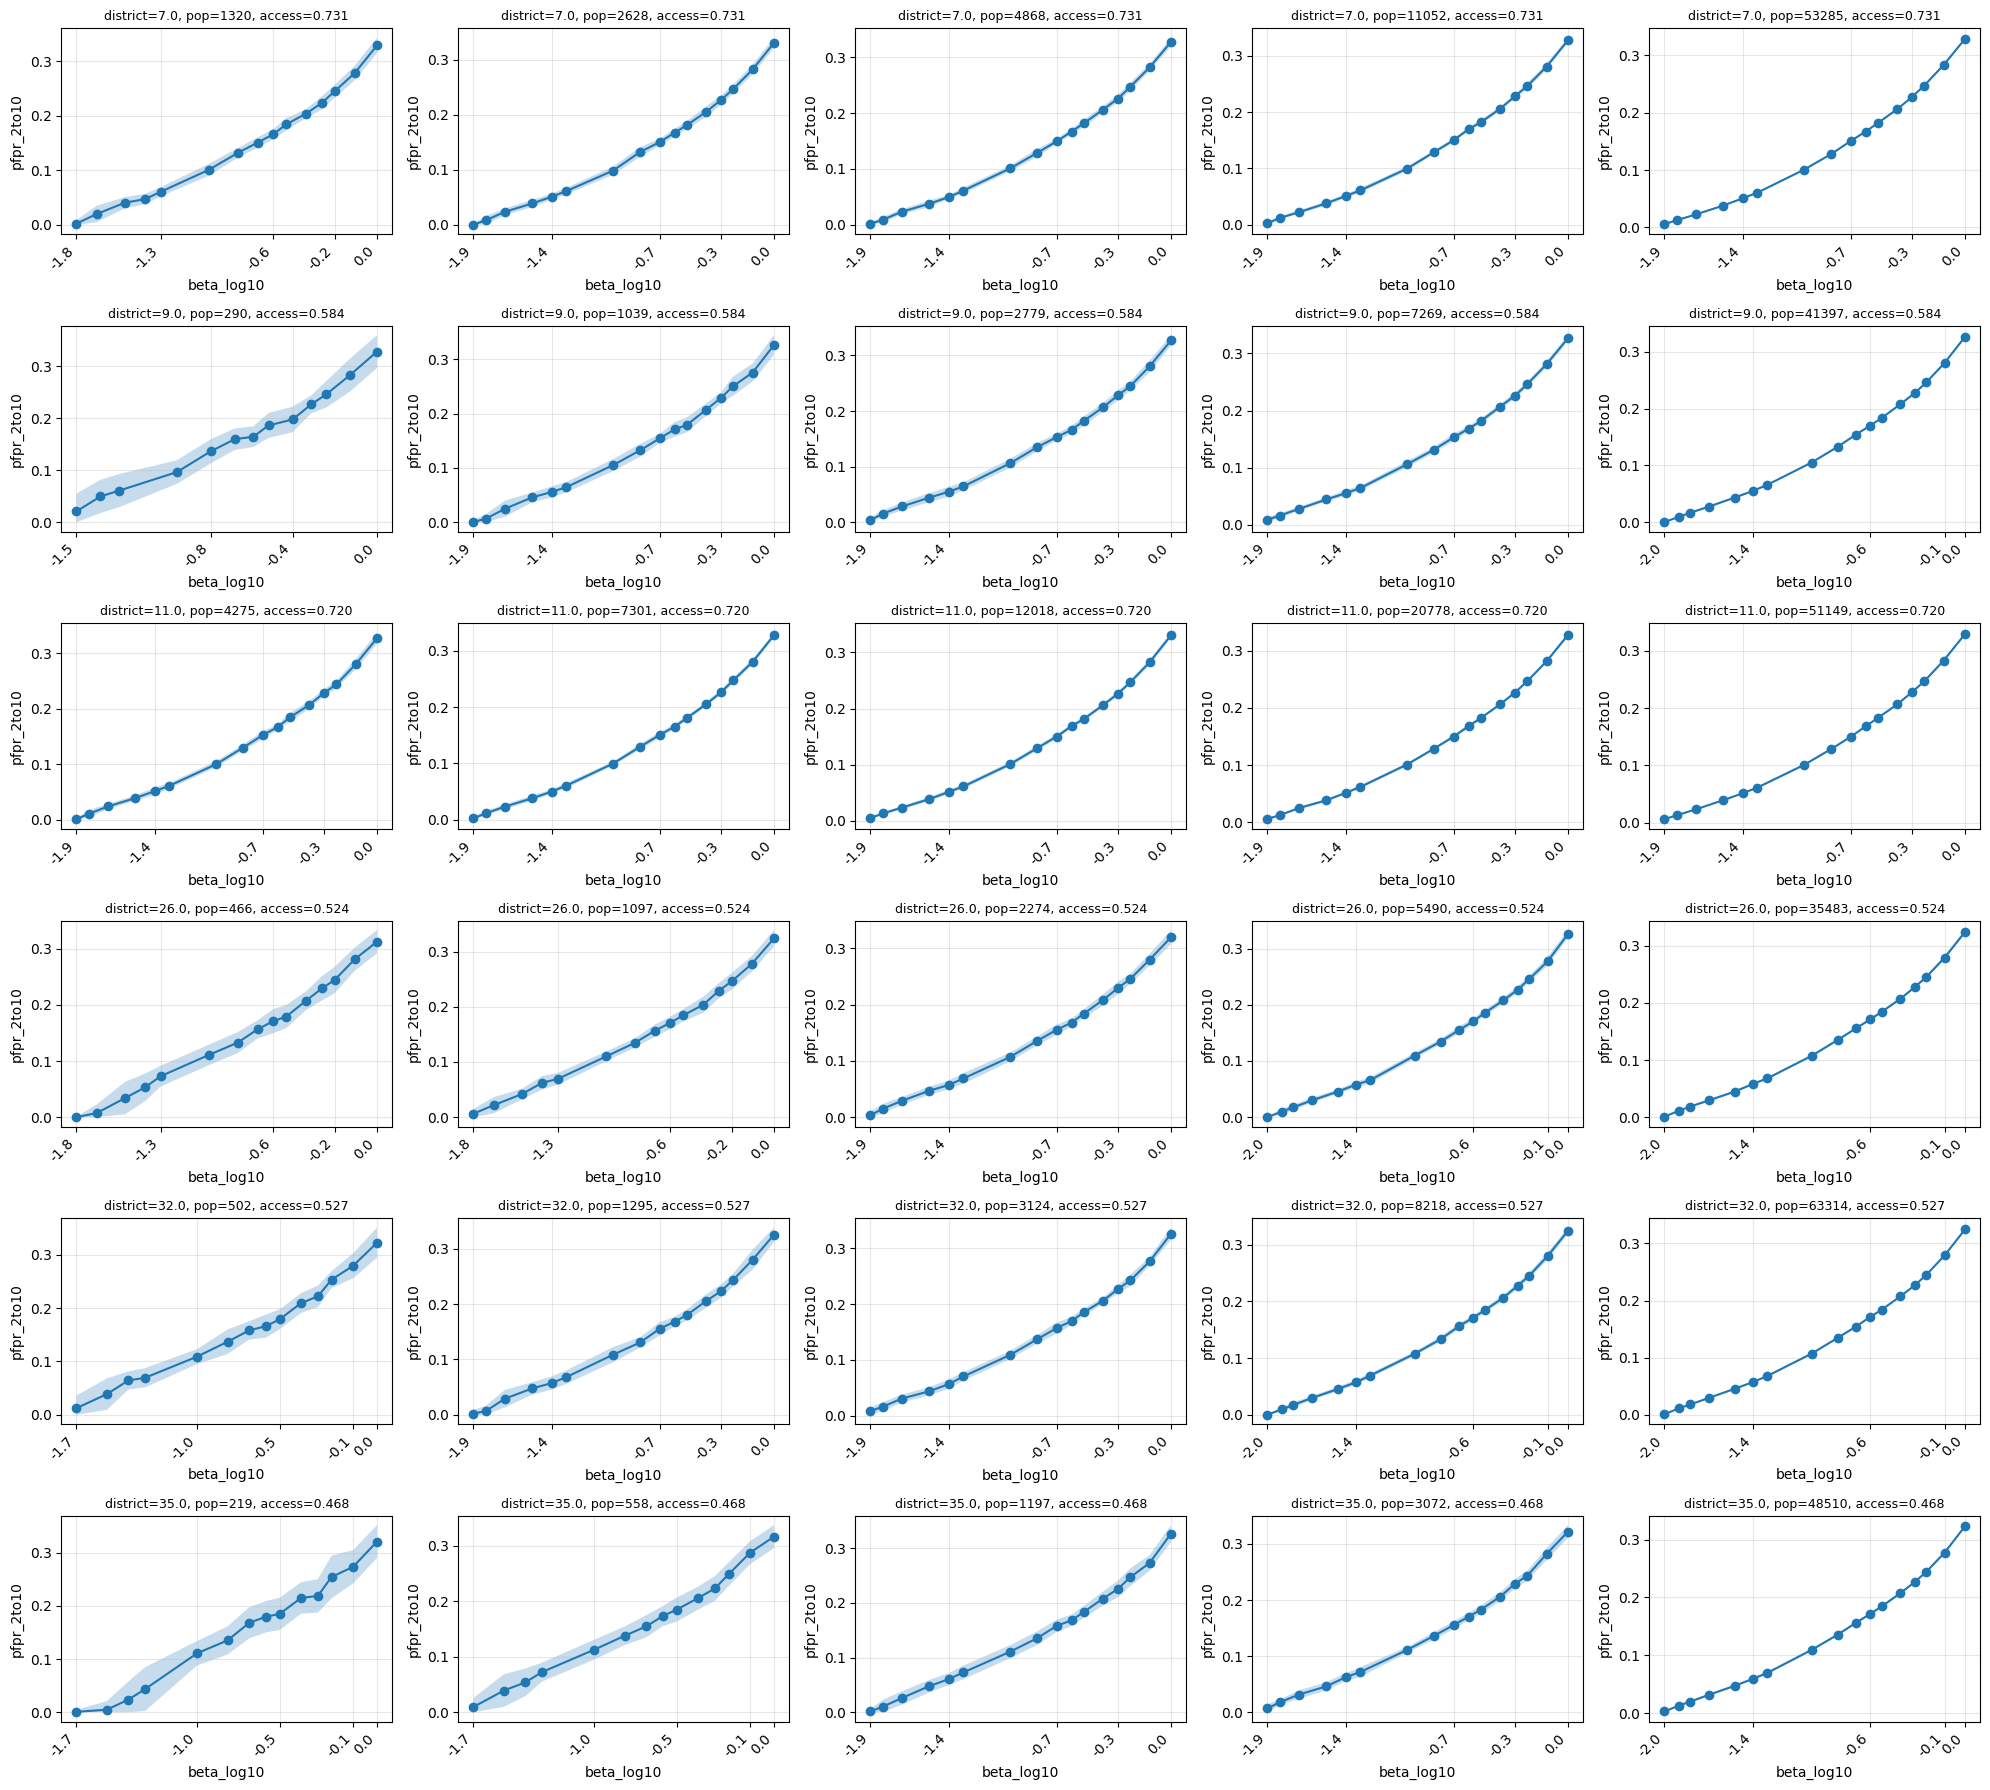

<Figure size 640x480 with 0 Axes>

In [ ]:
df = means.copy()

pfpr_col = "pfpr_2to10"          # or pfpr_under5 / pfpr_all
std_col  = f"{pfpr_col}_std"     # matches the *_std names from .agg()

# keep only rows that really have data (include the std col)
plot_df = df.dropna(subset=["district_id", "beta", "population_bin", "access_rate", pfpr_col]).copy()
plot_df = plot_df[plot_df[pfpr_col] > 0].copy()
plot_df["beta_log10"] = plot_df["beta"].apply(lambda b: math.log10(b) if b > 0 else float("-inf"))

grouped = (
    plot_df.groupby(["district_id", "population_bin", "access_rate"])
    .filter(lambda g: len(g) >= 1)
    .sort_values(["district_id", "population_bin", "access_rate", "beta_log10"])
)

grouped.to_csv(f"{analysis_path}/calibration_means_filtered_for_plotting.csv", index=False)

pairs = (
    grouped[["district_id", "population_bin", "access_rate"]]
    .drop_duplicates()
    .sort_values(["district_id", "population_bin", "access_rate"])
    .values.tolist()
)

n = len(pairs)
ncols = 5
nrows = math.ceil(n / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(4*ncols, 3*nrows), squeeze=False)
axes = axes.flatten()

index = 0

for ax, (unit_id, pop_bin, access_rate) in zip(axes, pairs):
    index += 1
    print(f"{index}/{len(pairs)} Plotting district_id={unit_id}, population_bin={pop_bin}, access_rate={access_rate:.3f}")
    g = grouped[
        (grouped["district_id"] == unit_id) &
        (grouped["population_bin"] == pop_bin) &
        (grouped["access_rate"] == access_rate)
    ].sort_values("beta_log10")

    x    = g["beta_log10"].to_numpy()
    mean = g[pfpr_col].to_numpy()
    # std may be NaN for single-rep groups; treat those as 0-width band
    std  = g[std_col].to_numpy() if std_col in g else None

    ax.plot(x, mean, marker="o", linewidth=1.5, label="mean")

    if std is not None:
        std_filled = pd.Series(std).fillna(0).to_numpy()
        lower = mean - std_filled
        upper = mean + std_filled
        # PfPR is a fraction in [0,1]; clip so the band doesn't dip below 0
        lower = lower.clip(min=0)
        ax.fill_between(x, lower, upper, alpha=0.25, label="±1 std")

    ax.set_title(f"district={unit_id}, pop={pop_bin:g}, access={access_rate:.3f}", fontsize=9)
    ax.set_ylabel(pfpr_col)
    ax.set_xlabel("beta_log10")
    ax.grid(True, alpha=0.3)

    # show at most 4 beta ticks per subplot
    beta_vals = g["beta_log10"].tolist()
    max_ticks = 4
    if len(beta_vals) <= max_ticks:
        tick_vals = beta_vals
    else:
        step = math.ceil(len(beta_vals) / max_ticks)
        tick_vals = beta_vals[::step]
        if tick_vals[-1] != beta_vals[-1]:
            tick_vals.append(beta_vals[-1])

    ax.set_xticks(tick_vals)
    ax.set_xticklabels([f"{b:.1f}" for b in tick_vals], rotation=45, ha="right")

for ax in axes[len(pairs):]:
    ax.axis("off")

plt.tight_layout()
plt.show()
# plt.savefig(f"{analysis_path}/calibration_means_plots_log10.png", dpi=300)

### Fit 2 segments sigmoid

In [32]:
"""
Standalone: fit + plot beta -> PfPR for every (district, population_bin, access_rate).

Modes:

1. If TRANSITION_BETA > 0:
   Use continuous two-segment model:
       - Linear for beta <= TRANSITION_BETA
       - Sigmoid for beta > TRANSITION_BETA
       - Sigmoid is anchored to the linear endpoint

2. If TRANSITION_BETA <= 0:
   Use one sigmoid over all beta values.
"""



# ----------------------------------------------------------------------
# Config
# ----------------------------------------------------------------------
# TRANSITION_BETA = -1       # <= 0 means use single sigmoid only

PFPR_COL = "pfpr_2to10"    # or "pfpr_under5" / "pfpr_all"
NCOLS = 4
DISTRICT_FILTER = None

INPUT_CSV = f"{analysis_path}/calibration_means_filtered_for_plotting.csv"


# ----------------------------------------------------------------------
# Basic model helpers
# ----------------------------------------------------------------------
def logistic(z):
    z = np.clip(z, -700, 700)
    return 1.0 / (1.0 + np.exp(-z))


def sigmoid(x, L, k, x0, b):
    return b + L / (1.0 + np.exp(-k * (x - x0)))


def continuous_sigmoid(x, L, k, x0, x_transition, y_transition):
    """
    Sigmoid anchored at transition point.

    continuous_sigmoid(x_transition) == y_transition
    """
    s = logistic(k * (x - x0))
    s_transition = logistic(k * (x_transition - x0))

    denom = 1.0 - s_transition
    denom = np.maximum(denom, 1e-8)

    return y_transition + L * (s - s_transition) / denom


def model_key(district_id, population_bin, access_rate) -> str:
    return f"{float(district_id)}_{float(population_bin)}_{float(access_rate)}"


def use_transition_mode(transition_beta_threshold):
    return transition_beta_threshold is not None and transition_beta_threshold > 0


# ----------------------------------------------------------------------
# Fit helpers
# ----------------------------------------------------------------------
def _fit_single_sigmoid(log_beta, y):
    log_beta = np.asarray(log_beta, dtype=float)
    y = np.asarray(y, dtype=float)

    p0 = [
        max(y.max() - y.min(), 1e-3),   # L
        1.0,                            # k
        float(np.median(log_beta)),     # x0
        float(y.min()),                 # b
    ]

    popt, _ = curve_fit(
        sigmoid,
        log_beta,
        y,
        p0=p0,
        bounds=(
            [0.0, 0.01, -6.0, 0.0],
            [1.0, 20.0, 3.0, 1.0],
        ),
        maxfev=50000,
    )

    return popt


def _fit_continuous_sigmoid(log_beta, y, x_transition, y_transition):
    log_beta = np.asarray(log_beta, dtype=float)
    y = np.asarray(y, dtype=float)

    y_transition = float(np.clip(y_transition, 0.0, 1.0))
    max_remaining = max(1.0 - y_transition, 1e-4)

    p0 = [
        min(max(y.max() - y_transition, 1e-3), max_remaining),  # L
        1.0,                                                    # k
        float(np.median(log_beta)),                             # x0
    ]

    popt, _ = curve_fit(
        lambda x, L, k, x0: continuous_sigmoid(
            x,
            L,
            k,
            x0,
            x_transition,
            y_transition,
        ),
        log_beta,
        y,
        p0=p0,
        bounds=(
            [0.0, 0.01, -6.0],
            [max_remaining, 20.0, 3.0],
        ),
        maxfev=50000,
    )

    return popt


# ----------------------------------------------------------------------
# Fit models
# ----------------------------------------------------------------------
''' Takes a dataframe of means, and returns a dict of models. '''
def fit_models(
    means,
    pfpr_col=PFPR_COL,
    transition_beta_threshold=-1,
):
    models = {}

    transition_mode = use_transition_mode(transition_beta_threshold)

    pairs = (
        means[["district_id", "population_bin", "access_rate"]]
        .drop_duplicates()
        .sort_values(["district_id", "population_bin", "access_rate"])
        .values.tolist()
    )

    if transition_mode:
        x_transition = np.log10(transition_beta_threshold)
    else:
        x_transition = None

    for district_id, pop_bin, access_rate in pairs:
        print(
            f"fitting {model_key(district_id, pop_bin, access_rate)}"
        )
        key = model_key(district_id, pop_bin, access_rate)

        g = means[
            (means["district_id"] == district_id) &
            (means["population_bin"] == pop_bin) &
            (means["access_rate"] == access_rate)
        ].sort_values("beta").copy()

        g = g[
            np.isfinite(g["beta"]) &
            np.isfinite(g[pfpr_col]) &
            (g["beta"] > 0)
        ]

        if g.empty:
            continue

        entry = {
            "district_id": float(district_id),
            "population_bin": float(pop_bin),
            "access_rate": float(access_rate),
        }

        # --------------------------------------------------------------
        # Case 1: TRANSITION_BETA <= 0
        # Single sigmoid over all beta values
        # --------------------------------------------------------------
        if not transition_mode:
            entry["split_mode"] = "single_sigmoid"

            if len(g) >= 4:
                try:
                    popt = _fit_single_sigmoid(
                        np.log10(g["beta"]),
                        g[pfpr_col].to_numpy(),
                    )

                    entry["sigmoid"] = {
                        "popt": popt,
                    }

                    models[key] = entry

                except Exception as e:
                    print(
                        f"Single sigmoid fit failed: "
                        f"d={district_id}, pop={pop_bin}, acc={access_rate}: {e}"
                    )

            continue

        # --------------------------------------------------------------
        # Case 2: TRANSITION_BETA > 0
        # Continuous two-segment model
        # --------------------------------------------------------------
        entry["split_mode"] = "continuous_two_segment"

        lin = g[
            (g["beta"] > 0) &
            (g["beta"] <= transition_beta_threshold)
        ]

        if len(lin) >= 2:
            slope, intercept, r, p, se = linregress(
                np.log10(lin["beta"]),
                lin[pfpr_col],
            )

            entry["linear"] = {
                "slope": float(slope),
                "intercept": float(intercept),
                "r_squared": float(r ** 2),
            }

            y_transition = slope * x_transition + intercept
            y_transition = float(np.clip(y_transition, 0.0, 1.0))

        else:
            closest_idx = (g["beta"] - transition_beta_threshold).abs().idxmin()
            y_transition = float(np.clip(g.loc[closest_idx, pfpr_col], 0.0, 1.0))

        entry["transition"] = {
            "beta": float(transition_beta_threshold),
            "log_beta": float(x_transition),
            "y": float(y_transition),
        }

        sig = g[g["beta"] > transition_beta_threshold]

        if len(sig) >= 3:
            try:
                popt = _fit_continuous_sigmoid(
                    np.log10(sig["beta"]),
                    sig[pfpr_col].to_numpy(),
                    x_transition=x_transition,
                    y_transition=y_transition,
                )

                entry["sigmoid"] = {
                    "popt": popt,
                }

            except Exception as e:
                print(
                    f"Continuous sigmoid fit failed: "
                    f"d={district_id}, pop={pop_bin}, acc={access_rate}: {e}"
                )

        if "linear" in entry or "sigmoid" in entry:
            models[key] = entry

    print(f"Fitted {len(models)} / {len(pairs)} groups.")
    return models


# ----------------------------------------------------------------------
# Forward evaluation
# ----------------------------------------------------------------------
def eval_forward(
    params,
    beta,
    transition_beta_threshold= -1,
):
    if beta <= 0:
        return np.nan

    log_b = np.log10(beta)
    split_mode = params.get("split_mode")

    # --------------------------------------------------------------
    # Single sigmoid mode
    # --------------------------------------------------------------
    if split_mode == "single_sigmoid":
        if "sigmoid" not in params:
            return np.nan

        y = sigmoid(log_b, *params["sigmoid"]["popt"])
        return float(np.clip(y, 0.0, 1.0))

    # --------------------------------------------------------------
    # Continuous two-segment mode
    # --------------------------------------------------------------
    if split_mode == "continuous_two_segment":
        x_transition = params["transition"]["log_beta"]
        y_transition = params["transition"]["y"]

        if beta <= transition_beta_threshold:
            if "linear" in params:
                y = (
                    params["linear"]["slope"] * log_b +
                    params["linear"]["intercept"]
                )
                return float(np.clip(y, 0.0, 1.0))

            return float(y_transition)

        if "sigmoid" in params:
            L, k, x0 = params["sigmoid"]["popt"]

            y = continuous_sigmoid(
                log_b,
                L,
                k,
                x0,
                x_transition,
                y_transition,
            )

            return float(np.clip(y, 0.0, 1.0))

        if "linear" in params:
            y = (
                params["linear"]["slope"] * log_b +
                params["linear"]["intercept"]
            )
            return float(np.clip(y, 0.0, 1.0))

    return np.nan


# ----------------------------------------------------------------------
# Plot fits
# ----------------------------------------------------------------------
def plot_fits(
    models,
    means,
    pfpr_col=PFPR_COL,
    transition_beta_threshold= -1,
    ncols=NCOLS,
):
    std_col = f"{pfpr_col}_std"
    transition_mode = use_transition_mode(transition_beta_threshold)

    pairs = (
        means[["district_id", "population_bin", "access_rate"]]
        .drop_duplicates()
        .sort_values(["district_id", "population_bin", "access_rate"])
        .values.tolist()
    )

    n = len(pairs)
    nrows = math.ceil(n / ncols)

    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=(4 * ncols, 3 * nrows),
        squeeze=False,
    )

    axes = axes.flatten()
    beta_plot = np.logspace(-3, 1, 2000)

    for ax, (district_id, pop_bin, access_rate) in zip(axes, pairs):
        g = means[
            (means["district_id"] == district_id) &
            (means["population_bin"] == pop_bin) &
            (means["access_rate"] == access_rate)
        ].sort_values("beta")

        # --------------------------------------------------------------
        # Data
        # --------------------------------------------------------------
        ax.plot(
            g["beta"],
            g[pfpr_col],
            "o",
            markersize=4,
            label="Data",
        )

        # --------------------------------------------------------------
        # Std band
        # --------------------------------------------------------------
        if std_col in g.columns and g[std_col].notna().any():
            std = g[std_col].fillna(0).to_numpy()
            mean = g[pfpr_col].to_numpy()

            lower = np.clip(mean - std, 0.0, 1.0)
            upper = np.clip(mean + std, 0.0, 1.0)

            ax.fill_between(
                g["beta"],
                lower,
                upper,
                alpha=0.12,
                label="±1 std",
            )

        # --------------------------------------------------------------
        # Transition line only if transition mode is active
        # --------------------------------------------------------------
        if transition_mode:
            ax.axvline(
                transition_beta_threshold,
                color="orange",
                lw=0.9,
                linestyle="--",
                label=f"β*={transition_beta_threshold}",
            )

        # --------------------------------------------------------------
        # Fitted curve
        # --------------------------------------------------------------
        key = model_key(district_id, pop_bin, access_rate)

        if key in models:
            params = models[key]

            yhat = np.array([
                eval_forward(params, b, transition_beta_threshold)
                for b in beta_plot
            ])

            ax.plot(
                beta_plot,
                yhat,
                color="black",
                lw=1.6,
                label="Fit",
            )

            if params.get("split_mode") == "single_sigmoid":
                title_suffix = "single_sigmoid"

            elif params.get("split_mode") == "continuous_two_segment":
                y_transition = params["transition"]["y"]

                ax.plot(
                    transition_beta_threshold,
                    y_transition,
                    marker="s",
                    markersize=3,
                    color="black",
                    label="Join",
                )

                has_lin = "linear" in params
                has_sig = "sigmoid" in params
                title_suffix = f"continuous: lin={has_lin}, sig={has_sig}"

            else:
                title_suffix = params.get("split_mode", "fit")

        else:
            title_suffix = "no fit"

        # --------------------------------------------------------------
        # Axis formatting
        # --------------------------------------------------------------
        ax.set_xscale("log")
        ax.set_xlim(1e-3, 10)
        ax.set_ylim(0, 1)

        ax.set_xlabel("beta")
        ax.set_ylabel(pfpr_col)

        ax.set_title(
            f"d={district_id:g}, pop={pop_bin:g}, acc={access_rate:.3f}\n"
            f"{title_suffix}",
            fontsize=8,
        )

        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=6, loc="upper left")

    for ax in axes[len(pairs):]:
        ax.axis("off")

    if transition_mode:
        title = (
            "PfPR vs Beta — continuous two-segment fits "
            "by district / population bin / access rate"
        )
    else:
        title = (
            "PfPR vs Beta — single-sigmoid fits "
            "by district / population bin / access rate"
        )

    fig.suptitle(title, fontsize=16)
    fig.tight_layout(rect=(0, 0, 1, 0.97))

    return fig

fitting 7.0_1320.0_0.731
fitting 7.0_2628.0_0.731
fitting 7.0_4868.0_0.731
fitting 7.0_11052.0_0.731
fitting 7.0_53285.0_0.731
fitting 9.0_290.0_0.584
fitting 9.0_1039.0_0.584
fitting 9.0_2779.0_0.584
fitting 9.0_7269.0_0.584
fitting 9.0_41397.0_0.584
fitting 11.0_4275.0_0.72
fitting 11.0_7301.0_0.72
fitting 11.0_12018.0_0.72
fitting 11.0_20778.0_0.72
fitting 11.0_51149.0_0.72
fitting 26.0_466.0_0.524
fitting 26.0_1097.0_0.524
fitting 26.0_2274.0_0.524
fitting 26.0_5490.0_0.524
fitting 26.0_35483.0_0.524
fitting 32.0_502.0_0.527
fitting 32.0_1295.0_0.527
fitting 32.0_3124.0_0.527
fitting 32.0_8218.0_0.527
fitting 32.0_63314.0_0.527
fitting 35.0_219.0_0.468
fitting 35.0_558.0_0.468
fitting 35.0_1197.0_0.468
fitting 35.0_3072.0_0.468
fitting 35.0_48510.0_0.468
Fitted 30 / 30 groups.


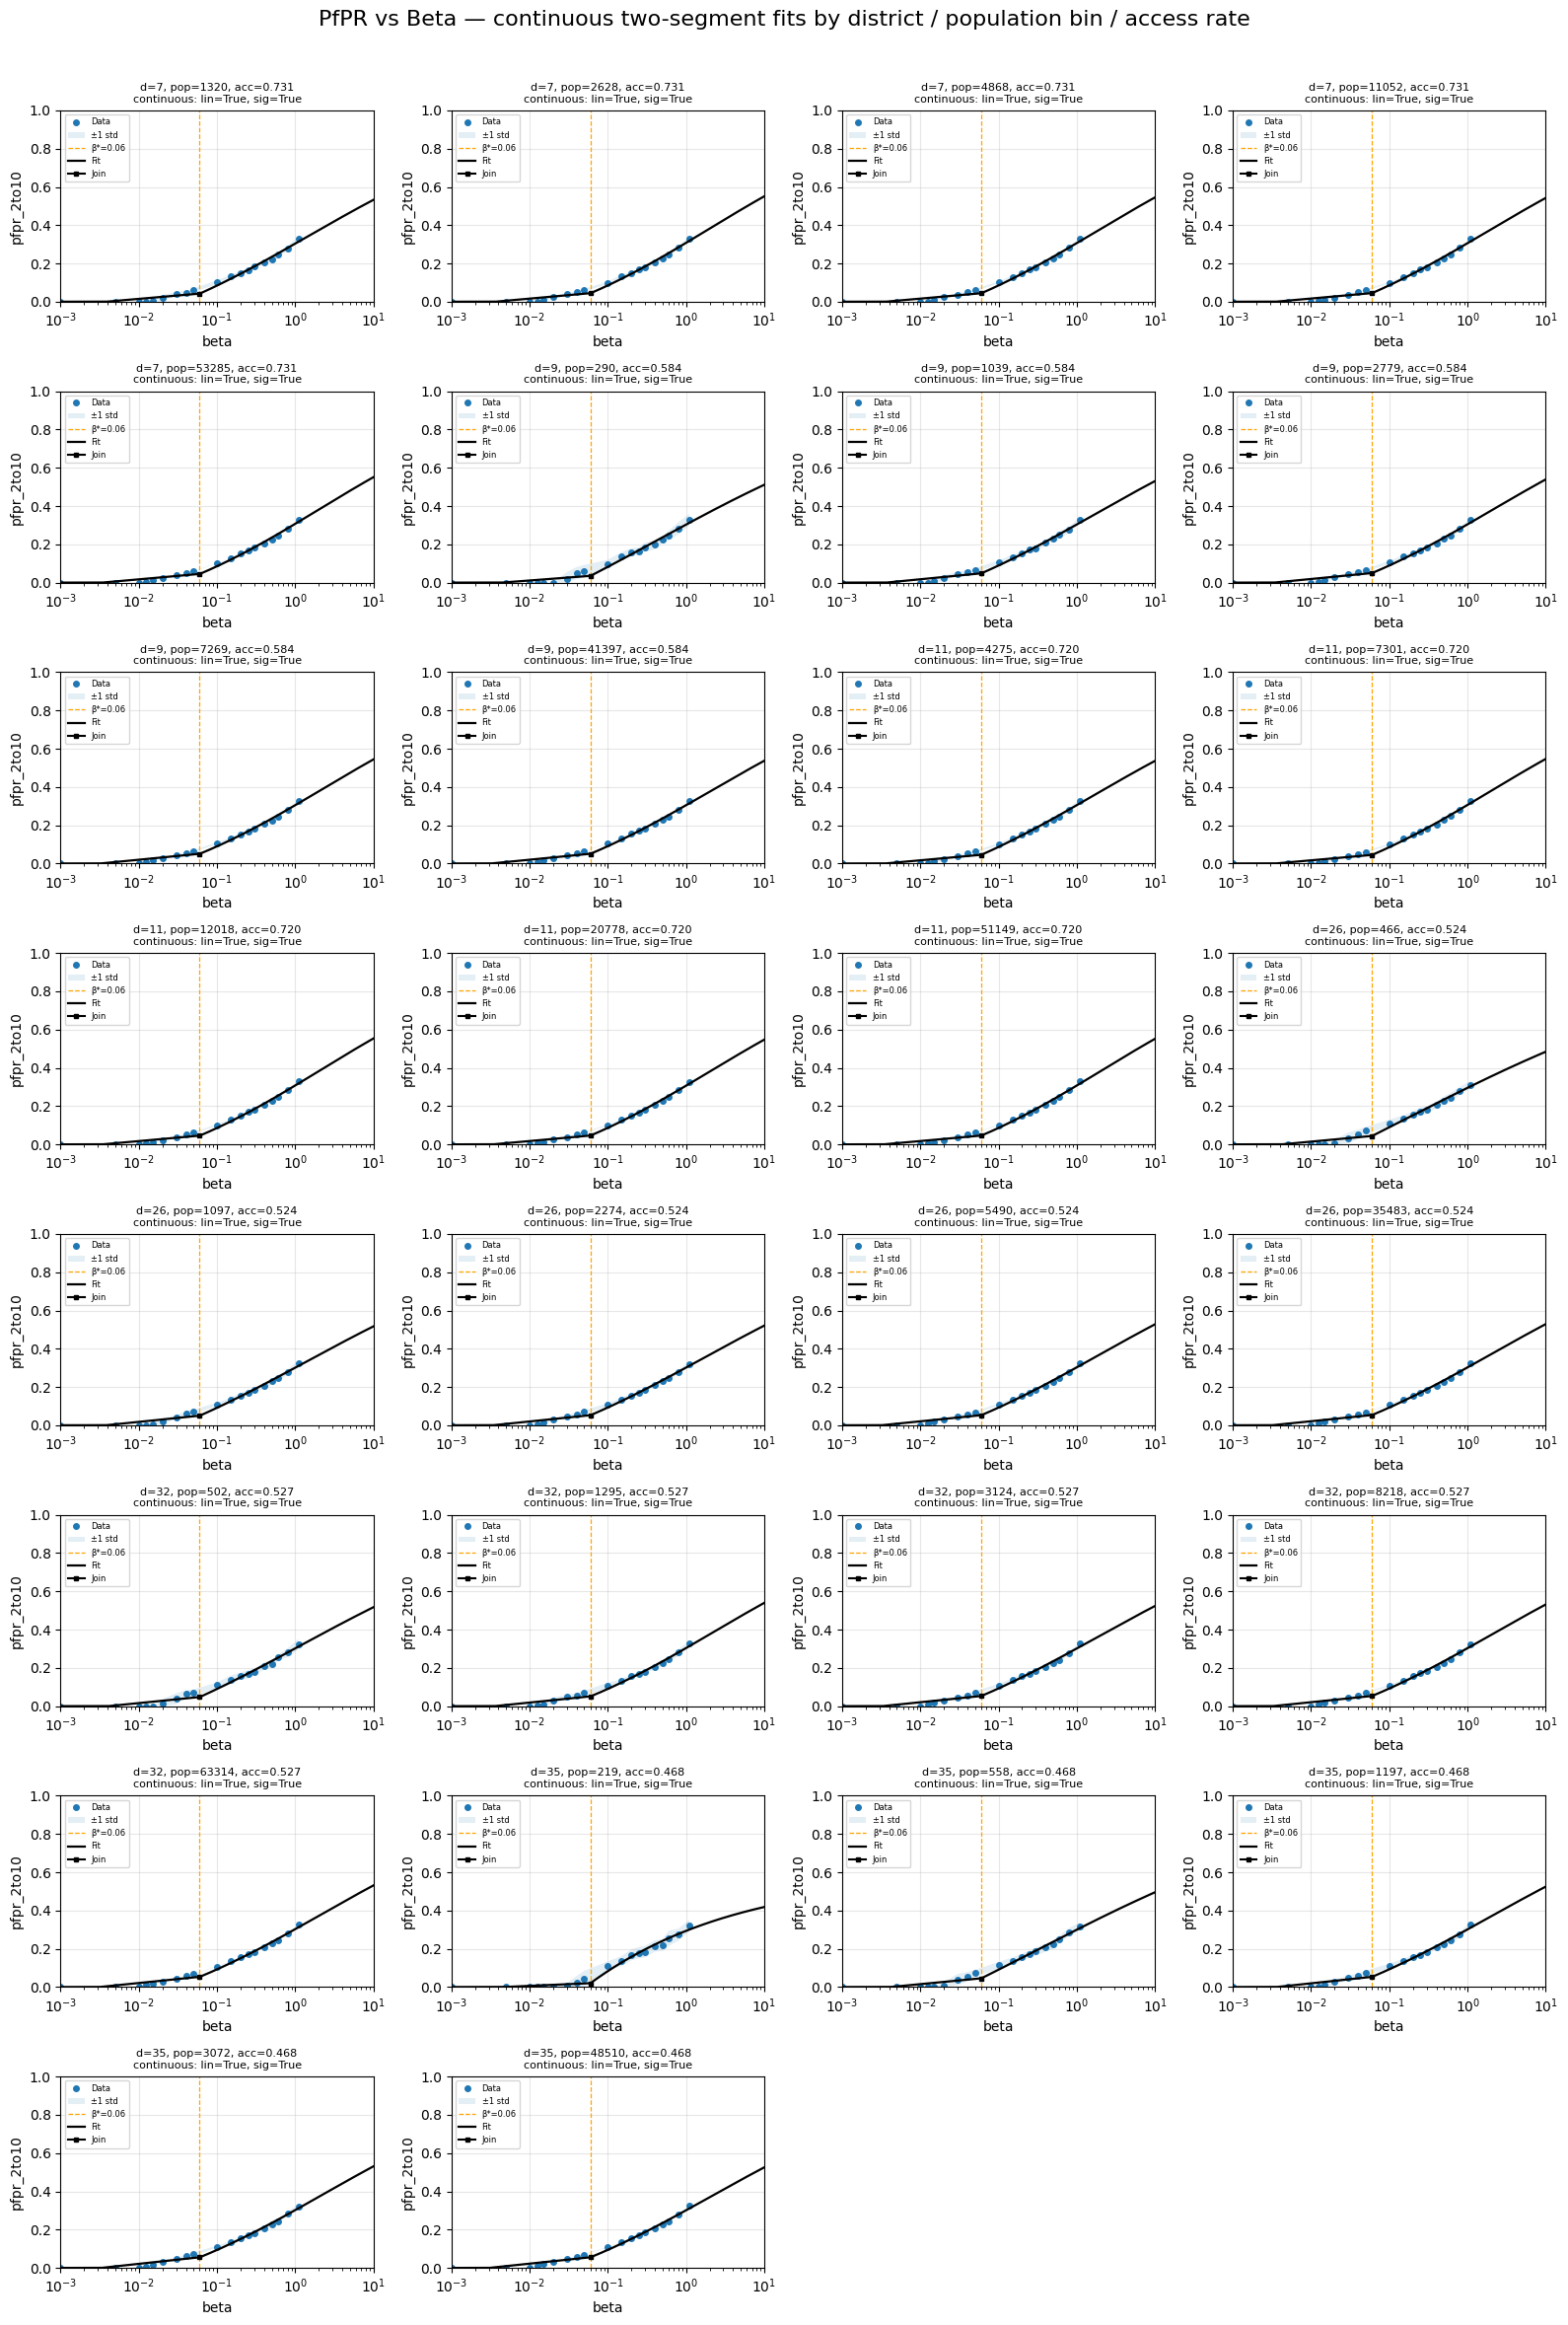

Saved fit params to calibration_10_one_pattern_25_replicates/analysis/continuous_two_segments_params_beta_0.06.csv


,model_id,district_id,population_bin,access_rate,split_mode,fit_status,has_linear,has_sigmoid,has_transition,transition_beta,...,linear_r_squared,linear_p_value,linear_std_err,sigmoid_L,sigmoid_k,sigmoid_x0,sigmoid_b,n_total,n_linear,n_sigmoid
0,7.0_1320.0_0.731,7.0,1320.0,0.731,continuous_two_segment,None,True,True,True,0.06,...,0.569939,None,None,0.957989,0.714356,0.171159,None,None,None,None
1,7.0_2628.0_0.731,7.0,2628.0,0.731,continuous_two_segment,None,True,True,True,0.06,...,0.604849,None,None,0.955687,0.801278,0.294036,None,None,None,None
2,7.0_4868.0_0.731,7.0,4868.0,0.731,continuous_two_segment,None,True,True,True,0.06,...,0.614288,None,None,0.956071,0.775583,0.267139,None,None,None,None
3,7.0_11052.0_0.731,7.0,11052.0,0.731,continuous_two_segment,None,True,True,True,0.06,...,0.627593,None,None,0.955336,0.765106,0.260610,None,None,None,None
4,7.0_53285.0_0.731,7.0,53285.0,0.731,continuous_two_segment,None,True,True,True,0.06,...,0.645754,None,None,0.954993,0.806552,0.307348,None,None,None,None


<Figure size 640x480 with 0 Axes>

In [ ]:
# ----------------------------------------------------------------------
# Fit + plot
# ----------------------------------------------------------------------
means = pd.read_csv(f"{analysis_path}/calibration_means.csv")

if DISTRICT_FILTER is not None:
    data_fit = means[means["district_id"].isin(DISTRICT_FILTER)].copy()
else:
    data_fit = means.copy()

TRANSITION_BETA = 0.06

models_map_two_seg = fit_models(
    data_fit,
    pfpr_col=PFPR_COL,
    transition_beta_threshold=TRANSITION_BETA,
)

fig = plot_fits(
    models_map_two_seg,
    data_fit,
    pfpr_col=PFPR_COL,
    transition_beta_threshold=TRANSITION_BETA,
    ncols=NCOLS,
)

plt.show()
# plt.savefig(f"{analysis_path}/calibration_fits.png", dpi=300)


# ----------------------------------------------------------------------
# Save fitted parameters to CSV
# ----------------------------------------------------------------------
rows = []

for model_id, params in models_map_two_seg.items():
    split_mode = params.get("split_mode")

    row = {
        "model_id": model_id,
        "district_id": params.get("district_id"),
        "population_bin": params.get("population_bin"),
        "access_rate": params.get("access_rate"),
        "split_mode": split_mode,
        "fit_status": params.get("fit_status", None),
        "has_linear": "linear" in params,
        "has_sigmoid": "sigmoid" in params,
        "has_transition": "transition" in params,
    }

    # -----------------------------
    # Transition params
    # -----------------------------
    if "transition" in params:
        tr = params["transition"]
        row.update({
            "transition_beta": tr.get("beta"),
            "transition_log_beta": tr.get("log_beta"),
            "transition_y": tr.get("y"),
        })
    else:
        row.update({
            "transition_beta": None,
            "transition_log_beta": None,
            "transition_y": None,
        })

    # -----------------------------
    # Linear params
    # -----------------------------
    if "linear" in params:
        lin = params["linear"]
        row.update({
            "linear_slope": lin.get("slope"),
            "linear_intercept": lin.get("intercept"),
            "linear_r_squared": lin.get("r_squared"),
            "linear_p_value": lin.get("p_value"),
            "linear_std_err": lin.get("std_err"),
        })
    else:
        row.update({
            "linear_slope": None,
            "linear_intercept": None,
            "linear_r_squared": None,
            "linear_p_value": None,
            "linear_std_err": None,
        })

    # -----------------------------
    # Sigmoid params
    # -----------------------------
    row.update({
        "sigmoid_L": None,
        "sigmoid_k": None,
        "sigmoid_x0": None,
        "sigmoid_b": None,
    })

    if "sigmoid" in params and "popt" in params["sigmoid"]:
        popt = params["sigmoid"]["popt"]

        if split_mode == "single_sigmoid":
            # popt = [L, k, x0, b]
            L, k, x0, b = popt

            row.update({
                "sigmoid_L": float(L),
                "sigmoid_k": float(k),
                "sigmoid_x0": float(x0),
                "sigmoid_b": float(b),
            })

        elif split_mode == "continuous_two_segment":
            # popt = [L, k, x0]
            # b is replaced by transition_y anchor
            L, k, x0 = popt

            row.update({
                "sigmoid_L": float(L),
                "sigmoid_k": float(k),
                "sigmoid_x0": float(x0),
                "sigmoid_b": None,
            })

        else:
            # fallback for safety
            if len(popt) == 4:
                L, k, x0, b = popt
                row.update({
                    "sigmoid_L": float(L),
                    "sigmoid_k": float(k),
                    "sigmoid_x0": float(x0),
                    "sigmoid_b": float(b),
                })

            elif len(popt) == 3:
                L, k, x0 = popt
                row.update({
                    "sigmoid_L": float(L),
                    "sigmoid_k": float(k),
                    "sigmoid_x0": float(x0),
                    "sigmoid_b": None,
                })

    # -----------------------------
    # Optional counts if present
    # -----------------------------
    row.update({
        "n_total": params.get("n_total"),
        "n_linear": params.get("n_linear"),
        "n_sigmoid": params.get("n_sigmoid"),
    })

    rows.append(row)


params_df = pd.DataFrame(rows)

params_df = params_df.sort_values(
    ["district_id", "population_bin", "access_rate"],
    na_position="last",
).reset_index(drop=True)

if TRANSITION_BETA > 0:
    out_csv = f"{analysis_path}/continuous_two_segments_params_beta_{TRANSITION_BETA}.csv"
else:
    out_csv = f"{analysis_path}/single_sigmoid_params.csv"

params_df.to_csv(out_csv, index=False)

print(f"Saved fit params to {out_csv}")
params_df.head()

In [34]:
data_fit

,district_id,beta,access_rate,population_bin,pfpr_under5,pfpr_under5_std,pfpr_2to10,pfpr_2to10_std,pfpr_all,pfpr_all_std
0,7.0,0.001,0.731,1320.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,7.0,0.001,0.731,2628.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,7.0,0.001,0.731,4868.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
3,7.0,0.001,0.731,11052.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,7.0,0.001,0.731,53285.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...
565,35.0,1.100,0.468,219.0,0.498469,0.049494,0.321081,0.030945,0.305947,0.025962
566,35.0,1.100,0.468,558.0,0.494561,0.036726,0.316743,0.020738,0.296345,0.019013
567,35.0,1.100,0.468,1197.0,0.506714,0.023080,0.326352,0.015451,0.307691,0.009607
568,35.0,1.100,0.468,3072.0,0.506286,0.014894,0.321838,0.011515,0.304447,0.005429


### Get beta map from fit curve

In [35]:
# ----------------------------------------------------------------------
# Helpers: key format must match fit_models()
# ----------------------------------------------------------------------
def model_key(district_id, population_bin, access_rate) -> str:
    return f"{float(district_id)}_{float(population_bin)}_{float(access_rate)}"

def parse_model_key(key):
    """
    Expected key format:
        district_id_population_bin_access_rate

    Example:
        32.0_1474.0_52.7
    """
    parts = str(key).split("_")
    if len(parts) != 3:
        return None

    try:
        return {
            "district_id": float(parts[0]),
            "population_bin": float(parts[1]),
            "access_rate": float(parts[2]),
        }
    except Exception:
        return None

def logistic(z):
    z = np.clip(z, -700, 700)
    return 1.0 / (1.0 + np.exp(-z))

# ----------------------------------------------------------------------
# Inverse functions
# ----------------------------------------------------------------------
def inverse_single_sigmoid(y, L, k, x0, b, eps=1e-10):
    """
    Inverse of:
        y = b + L / (1 + exp(-k * (x - x0)))

    Returns x = log10(beta).
    """
    if not np.isfinite(y) or not np.isfinite(L) or not np.isfinite(k):
        return None

    if L <= 0 or abs(k) < 1e-12:
        return None

    s = (y - b) / L

    # Clip to avoid infinite logit when y is outside fitted range.
    s = np.clip(s, eps, 1.0 - eps)

    x = x0 + np.log(s / (1.0 - s)) / k

    if np.isfinite(x):
        return float(x)

    return None

def inverse_continuous_sigmoid(
    y,
    L,
    k,
    x0,
    x_transition,
    y_transition,
    eps=1e-10,
):
    """
    Inverse of the anchored continuous sigmoid:
        y = y_transition + L * (s - s_transition) / (1 - s_transition)

    where:
        s = logistic(k * (x - x0))
        s_transition = logistic(k * (x_transition - x0))

    Returns x = log10(beta).
    """
    if not np.isfinite(y) or not np.isfinite(L) or not np.isfinite(k):
        return None

    if L <= 0 or abs(k) < 1e-12:
        return None

    s_transition = logistic(k * (x_transition - x0))
    denom = 1.0 - s_transition

    if denom <= eps:
        return None

    s = s_transition + ((y - y_transition) / L) * denom

    # Clip to avoid infinite logit when y is slightly outside fitted range.
    s = np.clip(s, eps, 1.0 - eps)

    x = x0 + np.log(s / (1.0 - s)) / k

    if np.isfinite(x):
        return float(x)

    return None

# ----------------------------------------------------------------------
# Predict beta from fitted model
# ----------------------------------------------------------------------
def unified_predict_beta(
    regression_params,
    model_id,
    pfpr,
    transition_beta_threshold,
):
    """
    Predict beta from PfPR using either:

    1. single_sigmoid
    2. continuous_two_segment
    """
    if model_id not in regression_params:
        return None

    params = regression_params[model_id]

    if not np.isfinite(pfpr):
        return None

    if pfpr == 0.0:
        return 0.0

    split_mode = params.get("split_mode", "single_sigmoid")

    # ------------------------------------------------------------------
    # Case 1: single sigmoid
    # ------------------------------------------------------------------
    if split_mode == "single_sigmoid":
        if "sigmoid" not in params or "popt" not in params["sigmoid"]:
            return None

        popt = params["sigmoid"]["popt"]

        if len(popt) != 4:
            return None

        L, k, x0, b = popt

        predicted_log_beta = inverse_single_sigmoid(
            pfpr,
            L,
            k,
            x0,
            b,
        )

        if predicted_log_beta is None:
            return None

        beta = 10 ** predicted_log_beta

        if np.isfinite(beta) and beta >= 0:
            return float(beta)

        return None

    # ------------------------------------------------------------------
    # Case 2: continuous two-segment model
    # ------------------------------------------------------------------
    if split_mode == "continuous_two_segment":
        if "transition" not in params:
            return None

        x_transition = params["transition"]["log_beta"]
        y_transition = params["transition"]["y"]

        # --------------------------------------------------------------
        # Use linear branch for PfPR below transition endpoint
        # --------------------------------------------------------------
        if pfpr <= y_transition and "linear" in params:
            slope = params["linear"]["slope"]
            intercept = params["linear"]["intercept"]

            if np.isfinite(slope) and abs(slope) > 1e-12:
                predicted_log_beta = (pfpr - intercept) / slope
                beta = 10 ** predicted_log_beta

                if np.isfinite(beta) and beta >= 0:
                    return float(beta)

        # --------------------------------------------------------------
        # Use anchored sigmoid branch for PfPR above transition endpoint
        # --------------------------------------------------------------
        if "sigmoid" in params and "popt" in params["sigmoid"]:
            popt = params["sigmoid"]["popt"]

            if len(popt) == 3:
                L, k, x0 = popt

                predicted_log_beta = inverse_continuous_sigmoid(
                    pfpr,
                    L,
                    k,
                    x0,
                    x_transition,
                    y_transition,
                )

                if predicted_log_beta is not None:
                    beta = 10 ** predicted_log_beta

                    if np.isfinite(beta) and beta >= 0:
                        return float(beta)

        # --------------------------------------------------------------
        # Fallback to linear if sigmoid failed
        # --------------------------------------------------------------
        if "linear" in params:
            slope = params["linear"]["slope"]
            intercept = params["linear"]["intercept"]

            if np.isfinite(slope) and abs(slope) > 1e-12:
                predicted_log_beta = (pfpr - intercept) / slope
                beta = 10 ** predicted_log_beta

                if np.isfinite(beta) and beta >= 0:
                    return float(beta)

        return None

    return None


# ----------------------------------------------------------------------
# Neighbor fallback: same district + same access rate
# ----------------------------------------------------------------------
def lookup_beta_from_neighbor_population(
    regression_params,
    target_key,
    pfpr,
    transition_beta_threshold,
    prefer_larger=True,
):
    """
    Fallback to neighboring population bin.

    Important:
    This stays within the same district and same treatment access.
    """
    parsed_target = parse_model_key(target_key)

    if parsed_target is None:
        return None

    target_district = parsed_target["district_id"]
    target_pop = parsed_target["population_bin"]
    target_access = parsed_target["access_rate"]

    candidates = []

    for key in regression_params.keys():
        parsed = parse_model_key(key)

        if parsed is None:
            continue

        district2 = parsed["district_id"]
        pop2 = parsed["population_bin"]
        access2 = parsed["access_rate"]

        if key == target_key:
            continue

        if not np.isclose(district2, target_district, atol=1e-6):
            continue

        if not np.isclose(access2, target_access, atol=1e-6):
            continue

        if prefer_larger:
            if pop2 > target_pop:
                candidates.append((pop2 - target_pop, pop2, key))
        else:
            candidates.append((abs(pop2 - target_pop), pop2, key))

    # If no larger bin exists, fall back to nearest bin in same district/access.
    if not candidates and prefer_larger:
        for key in regression_params.keys():
            parsed = parse_model_key(key)

            if parsed is None:
                continue

            district2 = parsed["district_id"]
            pop2 = parsed["population_bin"]
            access2 = parsed["access_rate"]

            if key == target_key:
                continue

            if not np.isclose(district2, target_district, atol=1e-6):
                continue

            if not np.isclose(access2, target_access, atol=1e-6):
                continue

            candidates.append((abs(pop2 - target_pop), pop2, key))

    if not candidates:
        return None

    candidates.sort(key=lambda x: (x[0], x[1]))
    neighbor_key = candidates[0][2]

    beta = unified_predict_beta(
        regression_params,
        neighbor_key,
        pfpr,
        transition_beta_threshold,
    )

    return beta


# ----------------------------------------------------------------------
# Access matching helper
# ----------------------------------------------------------------------
def access_match_mask(access_series, treatment_coverage, atol=1e-6):
    """
    Handles both possible scales:

        CSV access = 52.7 and raster = 52.7
        CSV access = 52.7 and raster = 0.527
    """
    access_values = access_series.astype(float)

    return (
        np.isclose(access_values, treatment_coverage, atol=atol) |
        np.isclose(access_values / 100.0, treatment_coverage, atol=atol) |
        np.isclose(access_values, treatment_coverage * 100.0, atol=atol)
    )


# ----------------------------------------------------------------------
# Generate beta raster
# ----------------------------------------------------------------------
def generate_beta_with_na(
    pfpr_data,
    district_population_data,
    district_data,
    population_data,
    treatment_data,
    regression_params,
    transition_beta_threshold,
    default_beta=0.1,
    population_tolerance=0.05,
    small_pop_threshold=0,
    return_debug=True,
):
    beta_data = np.full_like(pfpr_data, -9999.0, dtype=float)
    debug_rows = []

    # Make sure numeric columns are numeric.
    district_population_data = district_population_data.copy()
    district_population_data["district_id"] = district_population_data["district_id"].astype(float)
    district_population_data["population_low"] = district_population_data["population_low"].astype(float)
    district_population_data["population_high"] = district_population_data["population_high"].astype(float)
    district_population_data["population_bin"] = district_population_data["population_bin"].astype(float)
    district_population_data["treatment_access"] = district_population_data["treatment_access"].astype(float)

    stats = {
        "na_cells": 0,
        "pfpr_zero": 0,
        "no_matching_district_access": 0,
        "no_population_bin_within_tolerance": 0,
        "nearest_bin_used": 0,
        "direct_model_success": 0,
        "small_pop_neighbor_fallback_success": 0,
        "neighbor_fallback_success": 0,
        "default_fallback_used": 0,
    }

    nrows, ncols = pfpr_data.shape

    for i in range(nrows):
        for j in range(ncols):
            pfpr_value = pfpr_data[i, j]
            treatment_coverage = treatment_data[i, j]
            district_id = district_data[i, j]
            population = population_data[i, j]

            method = None
            selected_model_id = None
            selected_population_bin = None
            beta_value = None

            # ----------------------------------------------------------
            # NA handling
            # ----------------------------------------------------------
            if (
                pfpr_value == -9999 or
                treatment_coverage == -9999 or
                population == -9999 or
                district_id == -9999 or
                not np.isfinite(pfpr_value) or
                not np.isfinite(treatment_coverage) or
                not np.isfinite(population) or
                not np.isfinite(district_id)
            ):
                beta_data[i, j] = -9999
                stats["na_cells"] += 1
                method = "na"

                if return_debug:
                    debug_rows.append({
                        "row": i,
                        "col": j,
                        "district_id": district_id,
                        "population": population,
                        "pfpr": pfpr_value,
                        "treatment_coverage": treatment_coverage,
                        "population_bin": selected_population_bin,
                        "model_id": selected_model_id,
                        "beta": -9999,
                        "method": method,
                    })

                continue

            # ----------------------------------------------------------
            # PfPR zero means beta zero
            # ----------------------------------------------------------
            if pfpr_value == 0.0:
                beta_data[i, j] = 0.0
                stats["pfpr_zero"] += 1
                method = "pfpr_zero"

                if return_debug:
                    debug_rows.append({
                        "row": i,
                        "col": j,
                        "district_id": district_id,
                        "population": population,
                        "pfpr": pfpr_value,
                        "treatment_coverage": treatment_coverage,
                        "population_bin": selected_population_bin,
                        "model_id": selected_model_id,
                        "beta": 0.0,
                        "method": method,
                    })

                continue

            # ----------------------------------------------------------
            # Select rows from district_with_population_bins.csv
            # by district and treatment access
            # ----------------------------------------------------------
            district_mask = np.isclose(
                district_population_data["district_id"],
                float(district_id),
                atol=1e-6,
            )

            treatment_mask = access_match_mask(
                district_population_data["treatment_access"],
                float(treatment_coverage),
                atol=1e-6,
            )

            selected = district_population_data[district_mask & treatment_mask].copy()

            if selected.empty:
                # print(
                #     f"Warning: No matching district_id and treatment_access found "
                #     f"for district_id={district_id}, treatment_coverage={treatment_coverage}. "
                #     f"Using default beta={default_beta}."
                # )
                beta_value = default_beta
                beta_data[i, j] = beta_value
                stats["no_matching_district_access"] += 1
                stats["default_fallback_used"] += 1
                method = "default_no_matching_district_access"

                if return_debug:
                    debug_rows.append({
                        "row": i,
                        "col": j,
                        "district_id": district_id,
                        "population": population,
                        "pfpr": pfpr_value,
                        "treatment_coverage": treatment_coverage,
                        "population_bin": selected_population_bin,
                        "model_id": selected_model_id,
                        "beta": beta_value,
                        "method": method,
                    })

                continue

            # ----------------------------------------------------------
            # Find population bin from CSV
            # ----------------------------------------------------------
            selected["in_bin"] = (
                (selected["population_low"] * (1.0 - population_tolerance) <= population) &
                (population <= selected["population_high"] * (1.0 + population_tolerance))
            )

            matched = selected[selected["in_bin"]].copy()

            if not matched.empty:
                matched["center_dist"] = np.abs(matched["population_bin"] - population)
                selected_row = matched.sort_values("center_dist").iloc[0]
            else:
                selected = selected.copy()
                selected["center_dist"] = np.abs(selected["population_bin"] - population)
                selected_row = selected.sort_values("center_dist").iloc[0]

                stats["no_population_bin_within_tolerance"] += 1
                stats["nearest_bin_used"] += 1

            selected_population_bin = float(selected_row["population_bin"])
            selected_access = float(selected_row["treatment_access"])

            selected_model_id = model_key(
                district_id,
                selected_population_bin,
                selected_access,
            )

            # ----------------------------------------------------------
            # Small population fallback, if enabled
            # ----------------------------------------------------------
            if selected_population_bin < small_pop_threshold:
                beta_value = lookup_beta_from_neighbor_population(
                    regression_params,
                    selected_model_id,
                    pfpr_value,
                    transition_beta_threshold,
                    prefer_larger=True,
                )

                if beta_value is not None and np.isfinite(beta_value) and beta_value >= 0:
                    stats["small_pop_neighbor_fallback_success"] += 1
                    method = "small_pop_neighbor_fallback"

            # ----------------------------------------------------------
            # Direct model prediction
            # ----------------------------------------------------------
            if beta_value is None or not np.isfinite(beta_value) or beta_value < 0:
                beta_value = unified_predict_beta(
                    regression_params,
                    selected_model_id,
                    pfpr_value,
                    transition_beta_threshold,
                )

                if beta_value is not None and np.isfinite(beta_value) and beta_value >= 0:
                    stats["direct_model_success"] += 1
                    method = "direct_model"

            # ----------------------------------------------------------
            # Neighbor fallback within same district and same access
            # ----------------------------------------------------------
            if beta_value is None or not np.isfinite(beta_value) or beta_value < 0:
                neighbor_beta = lookup_beta_from_neighbor_population(
                    regression_params,
                    selected_model_id,
                    pfpr_value,
                    transition_beta_threshold,
                    prefer_larger=True,
                )

                if neighbor_beta is not None and np.isfinite(neighbor_beta) and neighbor_beta >= 0:
                    beta_value = neighbor_beta
                    stats["neighbor_fallback_success"] += 1
                    method = "neighbor_population_same_district_access"

            # ----------------------------------------------------------
            # Default fallback
            # ----------------------------------------------------------
            if beta_value is None or not np.isfinite(beta_value) or beta_value < 0:
                beta_value = default_beta
                stats["default_fallback_used"] += 1
                method = "default_fallback"

            beta_data[i, j] = float(beta_value)

            if return_debug:
                debug_rows.append({
                    "row": i,
                    "col": j,
                    "district_id": district_id,
                    "population": population,
                    "pfpr": pfpr_value,
                    "treatment_coverage": treatment_coverage,
                    "population_bin": selected_population_bin,
                    "model_id": selected_model_id,
                    "beta": beta_value,
                    "method": method,
                })

    if return_debug:
        return beta_data, stats, pd.DataFrame(debug_rows)

    return beta_data, stats


# ----------------------------------------------------------------------
# ASC I/O
# ----------------------------------------------------------------------
def write_asc_file(file_path, header, data, na_value=-9999):
    with open(file_path, "w") as file:
        for line in header:
            file.write(line)

        for row in data:
            vals = []

            for value in row:
                if not np.isfinite(value) or value == na_value:
                    vals.append(str(int(na_value)))
                else:
                    vals.append(f"{value:.6f}")

            file.write(" ".join(vals) + "\n")


def read_asc_file(file_path):
    with open(file_path, "r") as file:
        header = [next(file) for _ in range(6)]
        data = np.loadtxt(file, dtype=float)

    return header, data

In [36]:
# copy district district_with_population_bins.csv file from work/Calibration_Pipeline_v6_NG-SE/_pre_calibration_population_growth_rate_validation/analysis/district_with_population_bins.csv to analysis_path

shutil.copy(pre_calibration_analysis_path + "/district_with_population_bins.csv", analysis_path)
print(f"Copied district_with_population_bins.csv from {pre_calibration_analysis_path} to {analysis_path}")

Copied district_with_population_bins.csv from _pre_calibration_population_growth_rate_validation/analysis to calibration_10_one_pattern_25_replicates/analysis


In [37]:
small_pop_threshold = 0
data_path = Path("data")
pfpr_file_path = f"{data_path}/{country_code}_pfpr_{calibration_year}.asc"
population_path = f"{data_path}/{country_code}_population_projected_{calibration_year}.asc"
treatment_file_path = f"{data_path}/{country_code}_treatment_seeking_normalized.asc"
district_data_path = f"{data_path}/{country_code}_district.asc"

''' ^^ Use original district raster sequence here ^^  '''

district_population_path = f"{analysis_path}/district_with_population_bins.csv"

beta_file_path = f"{analysis_path}/{country_code}_beta.asc"
debug_csv_path = f"{analysis_path}/{country_code}_beta_cell_lookup_debug.csv"
district_summary_csv_path = f"{analysis_path}/{country_code}_beta_by_district_summary.csv"


# ----------------------------------------------------------------------
# Read ASC files
# ----------------------------------------------------------------------
pfpr_header, pfpr_data = read_asc_file(pfpr_file_path)
treatment_header, treatment_data = read_asc_file(treatment_file_path)
population_header, population_data = read_asc_file(population_path)
district_header, district_data = read_asc_file(district_data_path)

pfpr_data = pfpr_data.astype(float)
treatment_data = treatment_data.astype(float)
population_data = population_data.astype(float)
district_data = district_data.astype(float)


# ----------------------------------------------------------------------
# Read district population-bin CSV
# ----------------------------------------------------------------------
district_population_data = pd.read_csv(district_population_path)


# ----------------------------------------------------------------------
# Read calibration data and fit district-specific models
# ----------------------------------------------------------------------
calibration_csv = f"{analysis_path}/calibration_means_filtered_for_plotting.csv"

if not os.path.exists(calibration_csv):
    calibration_csv = f"{analysis_path}/calibration_means.csv"

means = pd.read_csv(calibration_csv)

# Normalize column names if needed.
if "access_rate" not in means.columns and "treatment_access" in means.columns:
    means = means.rename(columns={"treatment_access": "access_rate"})

if "population_bin" not in means.columns and "population" in means.columns:
    means = means.rename(columns={"population": "population_bin"})

means = means[
    np.isfinite(means["beta"]) &
    np.isfinite(means[PFPR_COL]) &
    (means["beta"] > 0) &
    (means[PFPR_COL] > 0)
].copy()

# Important:
# Use DISTRICT_FILTER=None when generating the final country-wide beta map.
if DISTRICT_FILTER is not None:
    data_fit = means[means["district_id"].isin(DISTRICT_FILTER)].copy()
else:
    data_fit = means.copy()

regression_params = fit_models(
    data_fit,
    pfpr_col=PFPR_COL,
    transition_beta_threshold=TRANSITION_BETA,
)


# ----------------------------------------------------------------------
# Generate beta data
# ----------------------------------------------------------------------
beta_data_with_na, stats, debug_df = generate_beta_with_na(
    pfpr_data=pfpr_data,
    district_population_data=district_population_data,
    district_data=district_data,
    population_data=population_data,
    treatment_data=treatment_data,
    regression_params=regression_params,
    transition_beta_threshold=TRANSITION_BETA,
    default_beta=0.1,
    population_tolerance=0.05,
    small_pop_threshold=small_pop_threshold,
    return_debug=True,
)

print(stats)


# ----------------------------------------------------------------------
# Write outputs
# ----------------------------------------------------------------------
write_asc_file(beta_file_path, pfpr_header, beta_data_with_na)

debug_df.to_csv(debug_csv_path, index=False)

valid_debug = debug_df[
    (debug_df["beta"] != -9999) &
    np.isfinite(debug_df["beta"])
].copy()

district_summary = (
    valid_debug
    .groupby("district_id", as_index=False)
    .agg(
        n_cells=("beta", "size"),
        beta_min=("beta", "min"),
        beta_mean=("beta", "mean"),
        beta_median=("beta", "median"),
        beta_max=("beta", "max"),
        n_default=("method", lambda x: (x == "default_fallback").sum()),
        n_direct=("method", lambda x: (x == "direct_model").sum()),
        n_neighbor=("method", lambda x: (x == "neighbor_population_same_district_access").sum()),
    )
)

district_summary.to_csv(district_summary_csv_path, index=False)

print(f"Saved beta ASC to: {beta_file_path}")
print(f"Saved cell-level debug CSV to: {debug_csv_path}")
print(f"Saved district summary CSV to: {district_summary_csv_path}")

# datas = {
#     "pfpr_data": pfpr_data,
#     "district_population_data": district_population_data,
#     "district_data": district_data,
#     "population_data": population_data,
# }

# print(f"\nPrinting district data:\n {district_data[district_data != -9999]}")

# for name, data in datas.items():
#     print(f"///// Printing {name} //////")
#     # info(f"Printing data:\n {data}")
#     info(f"Printing valid data:\n {data[data != -9999]}")
#     print(f"////////////////////////////\n")
info(f"Beta data with NA:\n {beta_data_with_na[beta_data_with_na != -9999]}")

district_summary.head()

fitting 7.0_1320.0_0.731
fitting 7.0_2628.0_0.731
fitting 7.0_4868.0_0.731
fitting 7.0_11052.0_0.731
fitting 7.0_53285.0_0.731
fitting 9.0_290.0_0.584
fitting 9.0_1039.0_0.584
fitting 9.0_2779.0_0.584
fitting 9.0_7269.0_0.584
fitting 9.0_41397.0_0.584
fitting 11.0_4275.0_0.72
fitting 11.0_7301.0_0.72
fitting 11.0_12018.0_0.72
fitting 11.0_20778.0_0.72
fitting 11.0_51149.0_0.72
fitting 26.0_466.0_0.524
fitting 26.0_1097.0_0.524
fitting 26.0_2274.0_0.524
fitting 26.0_5490.0_0.524
fitting 26.0_35483.0_0.524
fitting 32.0_502.0_0.527
fitting 32.0_1295.0_0.527
fitting 32.0_3124.0_0.527
fitting 32.0_8218.0_0.527
fitting 32.0_63314.0_0.527
fitting 35.0_219.0_0.468
fitting 35.0_558.0_0.468
fitting 35.0_1197.0_0.468
fitting 35.0_3072.0_0.468
fitting 35.0_48510.0_0.468
Fitted 30 / 30 groups.
{'na_cells': 51305, 'pfpr_zero': 0, 'no_matching_district_access': 0, 'no_population_bin_within_tolerance': 0, 'nearest_bin_used': 0, 'direct_model_success': 6851, 'small_pop_neighbor_fallback_success': 0, 'n

,district_id,n_cells,beta_min,beta_mean,beta_median,beta_max,n_default,n_direct,n_neighbor
0,7.0,1263,0.229194,0.927972,0.877050,2.155509,0,1263,0
1,9.0,840,0.279712,1.292266,1.223751,3.108009,0,840,0
2,11.0,255,0.324067,0.719830,0.658179,1.473442,0,255,0
3,26.0,1076,0.322635,0.906992,0.860775,2.844491,0,1076,0
4,32.0,1066,0.125167,0.467643,0.446507,1.152206,0,1066,0


In [38]:

def plot_raster_with_na(
    raster_data,
    output_path,
    title="Raster Plot",
    colorbar_label="Value",
    figsize=(10, 10),
    cmap="viridis",
    na_value=-9999,
):
    raster_plot = np.where(raster_data == na_value, np.nan, raster_data)

    valid_mask = raster_data != na_value
    if not np.any(valid_mask):
        raise ValueError("Raster contains no valid values.")

    raster_min = np.nanmin(raster_data[valid_mask])
    raster_max = np.nanmax(raster_data[valid_mask])

    print(f"{title} values (excluding NA): min={raster_min:.4f}, max={raster_max:.4f}")

    plt.figure(figsize=figsize)
    plt.imshow(
        raster_plot,
        vmin=raster_min,
        vmax=raster_max,
        cmap=cmap,
        zorder=2
    )
    plt.colorbar(label=colorbar_label)
    plt.title(title)
    plt.xlim(0, raster_plot.shape[1])
    plt.ylim(0, raster_plot.shape[0])
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.savefig(output_path)
    plt.show()

    print(f"Saved raster plot to {output_path}")

Inferred Beta from Observed PfPR and Access Rate values (excluding NA): min=0.1252, max=4.6899


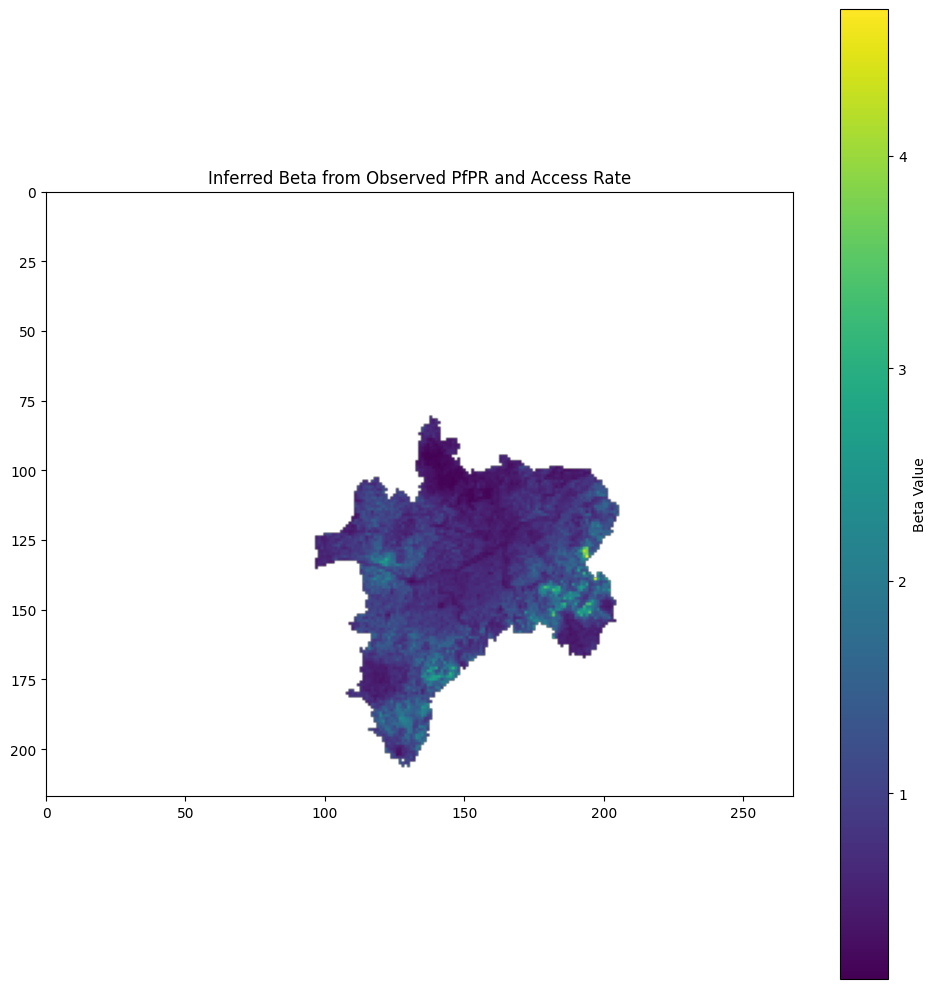

Saved raster plot to calibration_10_one_pattern_25_replicates/analysis/inferred_beta_raster.png


In [39]:
plot_raster_with_na(
    raster_data=beta_data_with_na,
    output_path=f"{analysis_path}/inferred_beta_raster.png",
    title="Inferred Beta from Observed PfPR and Access Rate",
    colorbar_label="Beta Value",
)

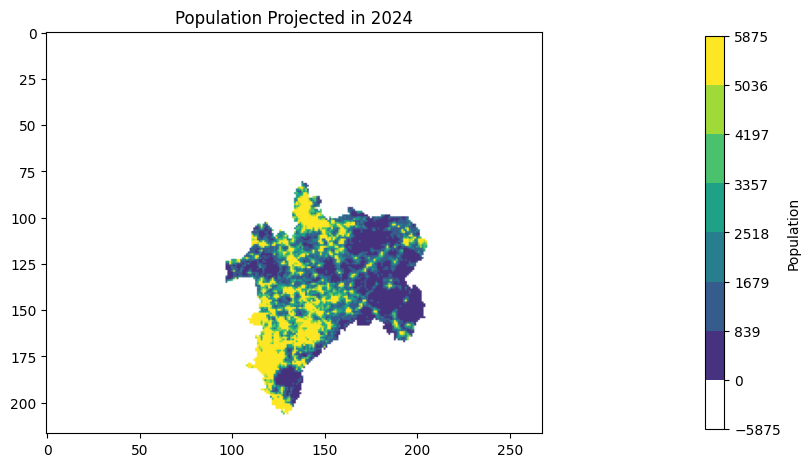

In [40]:
projected_population = population_data

# Where sim is nodata but obs exists → sim "contributed 0", so diff = -obs
missing_sim_mask = ~np.isfinite(projected_population)

# -----------------------
# Robust linear limits (prevents outliers from crushing contrast)
# -----------------------
combined = np.r_[projected_population[np.isfinite(projected_population)].ravel()]


# tweak these if needed
lo, hi = 2, 98
vmin = np.nanpercentile(combined, lo)
vmax = np.nanpercentile(combined, hi)

# -----------------------
# 8-band colormap for Population (Obs/Sim)
# -----------------------
n_bins = 8
bounds = np.r_[-vmax, 0, np.linspace(0, vmax, n_bins)[1:]]

base = plt.get_cmap("viridis", n_bins)        # discretize viridis into 8 colors
bg_white_color = np.array([[1,1,1,1]])
cmap_pop = ListedColormap(np.vstack([bg_white_color, plt.get_cmap("viridis", n_bins)(np.arange(1, n_bins))]))
norm_pop = BoundaryNorm(bounds, cmap_pop.N, clip=True)

# -----------------------
# Plot
# -----------------------
fig, ax = plt.subplots(figsize=(10, 6))
axes = np.array([ax, ax], dtype=object)

im1 = axes[1].imshow(projected_population, cmap=cmap_pop, norm=norm_pop, zorder=2)
axes[1].set_title(f"Population Projected in {calibration_year}")

# Colorbars (banded)
cbar1 = fig.colorbar(im1, ax=axes[:2], shrink=0.85, boundaries=bounds)
cbar1.set_label("Population")
cbar1.set_ticks(bounds)  # show band edges (or use bounds[::2] for fewer ticks)


plt.savefig(f"{data_path}/population_{calibration_year}_projected_map.png", dpi=200)
plt.show()

# plot_raster_with_na(
#     raster_data=population_data,
#     output_path=f"{analysis_path}/population_raster.png",
#     title="Population Raster",
#     colorbar_label="Population",
# )

In [41]:
mask = projected_population != -9999
projected_population_total = np.nansum(projected_population[mask])
print(f"Total projected population in {calibration_year}: {projected_population_total:,.0f}")

Total projected population in 2024: 26,716,457
